# Custom State
Node(Agent)간에 공유되는 상태정보를 커스터마이징할수 있다.

**최신 장소정보 공유**
- tool 장소검색api: naver/kakao/google map api(키워드 검색기반)
- tool 자연어 -> 검색을 위한 키워드추출
    - 나 여기 독산동인데, 여기 괜찮은 까페 추천해줘 -> 독산동 까페

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['TAVILY_API_KEY'] = os.getenv("tavily_key")
KAKAO_API_KEY = os.getenv('KAKAO_API_KEY')

In [19]:
from langchain.tools import tool
import requests
from pprint import pprint
from typing import List, TypedDict

class KakaoPlace(TypedDict):
    name:str
    address:str
    url:str

@tool
def kakao_place_search(query:str)-> List[KakaoPlace]:
    """
    카카오 장소검색 API를 호출하기 위한 도구
    Args:
        query: 검색어(키워드 기반)
    Returns:
        검색 결과
    """
    
    url = 'https://dapi.kakao.com/v2/local/search/keyword.json'
    headers = {
        'Authorization' : f"KakaoAK {KAKAO_API_KEY}"
    }
    params = {
        'query':query,
        'size':5
    }
    response = requests.get(url, headers=headers, params=params)
    data = response.json()['documents']
    
    return [ 
        {
            'name':place['place_name'],
            'address':place['address_name'],
            'url':place['place_url']
        }        
        for place in data
    ]
    
pprint(kakao_place_search.invoke({'query':'독산동 맛집'}))

[{'address': '서울 금천구 독산동 162-10',
  'name': '진영면옥',
  'url': 'http://place.map.kakao.com/280756271'},
 {'address': '서울 금천구 독산동 293-29',
  'name': '협진식당 5호집',
  'url': 'http://place.map.kakao.com/9623699'},
 {'address': '서울 금천구 독산동 1043',
  'name': 'KFC 독산동점',
  'url': 'http://place.map.kakao.com/1642588258'},
 {'address': '서울 금천구 독산동 144-10',
  'name': '한옥집 숯불갈비 서울본점',
  'url': 'http://place.map.kakao.com/500582252'},
 {'address': '서울 금천구 독산동 293-19',
  'name': '아로가 실비순대국',
  'url': 'http://place.map.kakao.com/16094602'}]


In [27]:
from langchain_core.prompts import PromptTemplate
from langchain.chat_models import init_chat_model

def extract_keyword(user_request: str) -> str:  # 사용자 요청을 장소검색 키워드로 변환하는 도구
    """
    사용자 요청에서 장소검색API를 사용하기 위한 짧고 명확한 키워드를 추출하는 도구
    장소검색도구(kakao_place_search)를 사용하기 전에 사용자의 요청을 먼저 변환하세요.
    """
    prompt = PromptTemplate.from_template('''
당신은 사용자의 요청을 장소검색에 필요한 키워드로 변환하는 전문가입니다.
장문의 사용자 요청에서 키워드를 한 문장으로 추출해주세요.
- 키워드는 띄워쓰기로 구분된 한 문장이어야 합니다.
- 다른 설명은 하지말고, 키워드만 추출합니다.

[사용자요청]
{user_request}


[예시]
- 여기 독산동인데, 소문난 맛집좀 알려줘봐 -> 독산동 맛집
- 부산 핫플 좀 알려줘봐 -> 부산 맛집

[금지어]
- 소문난
- 핫플
''')
    llm = init_chat_model('openai:gpt-4.1-mini')
    chain = prompt | llm
    response = chain.invoke({'user_request': user_request})
    return response.content.strip('"').strip("'")


In [28]:
print(extract_keyword('여기 독산동인데, 소문난 맛집좀 알려줘봐'))  # 지역+의도 키워드 추출
print(extract_keyword('이따 명동 갈건데, 맛집 리스트 좀 뽑아줘'))  # 장소 기반 맛집 키워드
print(extract_keyword('부산 핫플 좀 알려줘봐'))  # 금지어 제거 후 키워드
print(extract_keyword('강남에서 디저트 어디서 먹을까?'))  # 카테고리형 키워드
print(extract_keyword('수원에 호텔 어디가 좋아?'))  # 숙박 카테고리 키워드
print(extract_keyword('경기도 광주에 세차장 좀 찾아줘'))  # 업종 검색 키워드

독산동 맛집
명동 맛집
부산 관광지 명소
강남 디저트 맛집
수원 호텔
경기도 광주 세차장


# 그래프 구성

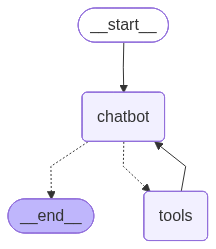

In [ ]:
# 사용자 입력 → 키워드 추출 → 카카오 장소검색 → 결과를 State에 저장하는 LangGraph 흐름

from langgraph.graph import StateGraph, START, END            # 그래프 워크플로우 구성 요소
from langgraph.graph.message import add_messages              # messages 누적 헬퍼
from typing import Annotated, Optional, List, TypedDict       # 타입 정의용
from langchain_core.messages import BaseMessage, ToolMessage  # 메시지 타입
from langgraph.prebuilt import ToolNode, tools_condition      # 툴 실행 노드 / 분기 조건

class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]      # 대화/중간결과를 계속 누적하는 공간
    search_query: Optional[str]                               # 추출된 검색 키워드 저장
    search_results: Optional[List[KakaoPlace]]                # 장소검색 결과 저장

model = init_chat_model('openai:gpt-4.1-mini')                # LLM 준비
tools = [kakao_place_search, extract_keyword]                 # 사용할 도구 목록
model_with_tools = model.bind_tools(tools)                    # LLM이 필요시 툴 호출 가능하게 바인딩

def chatbot(state: State):
    # 직전에 툴이 실행되어 ToolMessage가 들어온 경우 → 상태에 결과 반영
    if isinstance(state['messages'][-1], ToolMessage):        # 마지막 메시지가 툴 결과인지 확인
        if state['messages'][-1].name == 'extract_keyword':   # 키워드 추출 툴 결과면
            state['search_query'] = state['messages'][-1].content     # 검색어를 상태에 저장
        elif state['messages'][-1].name == 'kakao_place_search':      # 장소검색 툴 결과면
            state['search_results'] = state['messages'][-1].content   # 검색 결과를 상태에 저장

    response = model_with_tools.invoke(state['messages'])     # 누적된 메시지 기반으로 LLM 호출
    return {**state, 'messages': [response]}                  # 새 응답을 messages에 추가해 반환

workflow = StateGraph(State)                                  # 상태 기반 그래프 생성

workflow.add_node('chatbot', chatbot)                         # LLM 처리 노드
workflow.add_node('tools', ToolNode(tools))                   # 실제 툴 실행 노드

workflow.add_edge(START, 'chatbot')                           # 시작 → LLM 먼저 호출
workflow.add_conditional_edges('chatbot', tools_condition)    # LLM이 툴 필요 판단 시 tools로 분기
workflow.add_edge('tools', 'chatbot')                         # 툴 실행 후 다시 LLM으로 돌아감

graph = workflow.compile()                                    # 실행 가능한 그래프로 컴파일


In [ ]:
initial_state : State = {
    'messages' : [('human', '중랑구 맛집 추천해줘')],
    'search_query' : None,      # 키워드 추출
    'search_results' : None     # 장소 검색 결과
}

final_state =graph.invoke(initial_state) # 그래프 실행
final_state

{'messages': [HumanMessage(content='중랑구 맛집 추천해줘', additional_kwargs={}, response_metadata={}, id='04da5aff-c553-4605-98f4-650f711efabe'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 139, 'total_tokens': 177, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_75546bd1a7', 'id': 'chatcmpl-D7ar6xaZYaZEywZCT1zmPYpiiqq9D', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c4615-8131-73c2-86eb-dfdc9e519eda-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '중랑구 맛집 추천해줘'}, 'id': 'call_6lVt12jbKwQfGPKsxroSqL0O', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 139, 'ou

In [36]:
pprint(final_state)

{'messages': [HumanMessage(content='중랑구 맛집 추천해줘', additional_kwargs={}, response_metadata={}, id='04da5aff-c553-4605-98f4-650f711efabe'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 139, 'total_tokens': 177, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_75546bd1a7', 'id': 'chatcmpl-D7ar6xaZYaZEywZCT1zmPYpiiqq9D', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c4615-8131-73c2-86eb-dfdc9e519eda-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '중랑구 맛집 추천해줘'}, 'id': 'call_6lVt12jbKwQfGPKsxroSqL0O', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_token

# 그래프 디버깅

In [39]:
for msg in final_state['messages']:
    msg.pretty_print()

================================ Human Message =================================

중랑구 맛집 추천해줘
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_6lVt12jbKwQfGPKsxroSqL0O)
 Call ID: call_6lVt12jbKwQfGPKsxroSqL0O
  Args:
    user_request: 중랑구 맛집 추천해줘
================================= Tool Message =================================
Name: extract_keyword

중랑구 맛집
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_YrNiyy8vyMO2FgzUZDjuHrOB)
 Call ID: call_YrNiyy8vyMO2FgzUZDjuHrOB
  Args:
    query: 중랑구 맛집
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "울타리곱창", "address": "서울 중랑구 중화동 298-21", "url": "http://place.map.kakao.com/16376322"}, {"name": "홍이네옛날떡볶이", "address": "서울 중랑구 망우동 342-47", "url": "http://place.map.kakao.com/16061905"}, {"name": "부자돼소", "address": "서울 중랑구 면목동 91-61", "url": "h

In [43]:
initial_state : State = {
    'messages' : [('human', '중랑구 맛집 추천해줘')],
    'search_query' : None,      # 키워드 추출
    'search_results' : None     # 장소 검색 결과
}

for chunk in graph.stream(initial_state, stream_mode='updates'):
    for node, update in chunk.items():
        print(f'{node} node')
        update['messages'][-1].pretty_print()
    print()

chatbot node
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_4exSs12LsOzZcSbnSDmFxymk)
 Call ID: call_4exSs12LsOzZcSbnSDmFxymk
  Args:
    user_request: 중랑구 맛집 추천해줘

tools node
================================= Tool Message =================================
Name: extract_keyword

중랑구 맛집

chatbot node
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_xNhCFTHCbXkeqdNqSVOug48K)
 Call ID: call_xNhCFTHCbXkeqdNqSVOug48K
  Args:
    query: 중랑구 맛집

tools node
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "울타리곱창", "address": "서울 중랑구 중화동 298-21", "url": "http://place.map.kakao.com/16376322"}, {"name": "홍이네옛날떡볶이", "address": "서울 중랑구 망우동 342-47", "url": "http://place.map.kakao.com/16061905"}, {"name": "부자돼소", "address": "서울 중랑구 면목동 91-61", "url": "http://place.map.kakao.com/2120779454"}, {"n